In [1]:
# to prevent truncated image error with model.fit
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


*Loading the dataset*

In [3]:
!git clone https://github.com/Mahaalosaimi2000/disaster-recognition-using-CNN-.git

Cloning into 'disaster-recognition-using-CNN-'...
remote: Enumerating objects: 16844, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 16844 (delta 1), reused 1 (delta 0), pack-reused 16838 (from 1)
Receiving objects: 100% (16844/16844), 1.09 GiB | 40.95 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (17037/17037), done.


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


*import the needed libraries*

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import shutil
import random
import glob
import os
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.utils import to_categorical
import os
from sklearn.model_selection import train_test_split
from pathlib import Path
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import entropy
from tensorflow.keras.models import load_model
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Add, Reshape, Multiply
from tensorflow.keras.optimizers import SGD
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
dataset = "disaster-recognition-using-CNN-/Comprehensive Disaster Dataset(CDD)"

In [7]:

os.listdir(dataset)

['Non_Damage_Wildlife_Forest',
 'Human_Damage',
 'Non_Damage_human',
 'Non_Damage_Buildings_Street',
 'Water_Disaster',
 'Fire',
 'Traffic accident',
 'Infrastructure Damage',
 'Non_Damage_sea']

## Splitting Data into Train, Validation, and Test
We will split the data to 70% for training, 15% for validation, and 15% for testing

In [8]:
# Split data into train, validation, and test

# Base path for dataset
base_dataset_path = "disaster-recognition-using-CNN-/Comprehensive Disaster Dataset(CDD)"

# Get names of all disaster classes
disaster_classes = [d for d in os.listdir(base_dataset_path)
                    if os.path.isdir(os.path.join(base_dataset_path, d))]

print("Disaster classes found:")
for cls in disaster_classes:
    print(f"  - {cls}")

# Create folders for train, validation, and test
output_base_path = "Disaster_Data_Split"
os.makedirs(output_base_path, exist_ok=True)

# Create subdirectories for each phase (train, val, test)
for split in ['train', 'validation', 'test']:
    split_path = os.path.join(output_base_path, split)
    os.makedirs(split_path, exist_ok=True)
    for cls in disaster_classes:
        class_path = os.path.join(split_path, cls)
        os.makedirs(class_path, exist_ok=True)

print(f"\n Split folders created at: {output_base_path}")

Disaster classes found:
  - Non_Damage_Wildlife_Forest
  - Human_Damage
  - Non_Damage_human
  - Non_Damage_Buildings_Street
  - Water_Disaster
  - Fire
  - Traffic accident
  - Infrastructure Damage
  - Non_Damage_sea

 Split folders created at: Disaster_Data_Split


In [9]:
# Split each class into train, validation, and test (70%, 15%, and 15%)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

total_images = 0
split_summary = {}

for cls in disaster_classes:
    class_path = os.path.join(base_dataset_path, cls)
    images = os.listdir(class_path)
    images = [img for img in images if img.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))]

    total_images += len(images)
    split_summary[cls] = len(images)

    # Split images
    train_imgs, temp_imgs = train_test_split(images, test_size=(1-train_ratio), random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_ratio/(val_ratio+test_ratio), random_state=42)

    # Copy images to their folders
    # Copy training images
    for img in train_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(output_base_path, 'train', cls, img)
        shutil.copy(src, dst)

    # Copy validation images
    for img in val_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(output_base_path, 'validation', cls, img)
        shutil.copy(src, dst)

    # Copy test images
    for img in test_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(output_base_path, 'test', cls, img)
        shutil.copy(src, dst)

    print(f"{cls}: {len(images)} images → Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

print(f"Total images: {total_images}")

Non_Damage_Wildlife_Forest: 2271 images → Train: 1589, Val: 341, Test: 341
Human_Damage: 3016 images → Train: 2111, Val: 452, Test: 453
Non_Damage_human: 1055 images → Train: 738, Val: 158, Test: 159
Non_Damage_Buildings_Street: 3000 images → Train: 2099, Val: 450, Test: 451
Water_Disaster: 1035 images → Train: 724, Val: 155, Test: 156
Fire: 1693 images → Train: 1185, Val: 254, Test: 254
Traffic accident: 1181 images → Train: 826, Val: 177, Test: 178
Infrastructure Damage: 1511 images → Train: 1057, Val: 227, Test: 227
Non_Damage_sea: 2273 images → Train: 1591, Val: 341, Test: 341
Total images: 17035


In [10]:
# Update split data paths
train_img_path = os.path.join(output_base_path, 'train')
valid_img_path = os.path.join(output_base_path, 'validation')
test_img_path = os.path.join(output_base_path, 'test')

# Verify folders
print(" Split data paths:")
print(f"  Train: {train_img_path}")
print(f"  Validation: {valid_img_path}")
print(f"  Test: {test_img_path}")

print("\n Number of images in each folder:")
print(f"  Train: {sum([len(files) for r, d, files in os.walk(train_img_path)])} images")
print(f"  Validation: {sum([len(files) for r, d, files in os.walk(valid_img_path)])} images")
print(f"  Test: {sum([len(files) for r, d, files in os.walk(test_img_path)])} images")

 Split data paths:
  Train: Disaster_Data_Split/train
  Validation: Disaster_Data_Split/validation
  Test: Disaster_Data_Split/test

 Number of images in each folder:
  Train: 11920 images
  Validation: 2555 images
  Test: 2560 images


## Save Split Folder to Device
Compress and save split data for easy transfer and backup

In [ ]:
# to save the splitted dataset into google drive as zip file
shutil.make_archive('disaster_data_Splited_compresses', 'zip', '/content/Disaster_Data_Split')


'/content/disaster_data_Splited_compresses.zip'

In [ ]:
!cp -r /content/disaster_data_Splited_compresses.zip /content/drive/MyDrive/disaster-recognition-using-CNN

## Setting up Data Generators for Split Data
Apply ImageDataGenerator with data augmentation enhancements

ImageDataGenerator is a class from Keras/TensorFlow used to efficiently load images from folders and apply real-time data augmentation.
Why is it so useful?

1. It loads images directly from directories in batches
2. It automatically assigns labels based on folder names (each folder = one class).
3. It returns labels as one-hot encoded vectors when you use class_mode='categorical'.
4. It supports real-time data augmentation (rotation, zoom, flip, etc.) during training, which increases data diversity and improves model performance.
5. It integrates directly with model.fit and model.evaluate in Keras.

In summary: It handles all the steps of loading, transforming, splitting, encoding, and augmenting images, making training neural networks on image data much easier, faster, and more efficient.


# الكود اخذته من ذا الرابط
#https://medium.com/codex/have-photos-will-model-af804573cfe6
# و
# https://medium.com/data-science-collective/image-augumentation-using-deep-rbm-fc32e2190de8
# و
# https://medium.com/@kumudtraveldiaries/step-by-step-preprocessing-guide-for-images-in-both-cnn-and-dense-layer-pipelines-1994c3ad3e87

In [11]:

# For training data - with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,           # Rotate by 30 degrees
    zoom_range=0.3,# Zoom by 30%
    shear_range=0.1,             # Shear by 10%
    width_shift_range=0.2,       # Horizontal shift by 20%
    height_shift_range=0.2,      # Vertical shift by 20%
    horizontal_flip=True,        # Horizontal flip
    vertical_flip=False,
    brightness_range=[0.8, 1.2], # Adjust brightness by 20%
    fill_mode='nearest'          # Fill empty pixels
)

# For validation and test data - without Data Augmentation
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators from folders
train_generator = train_datagen.flow_from_directory(
    train_img_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    valid_img_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_img_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=42
)


print(f"\nDetected disaster classes: {train_generator.class_indices}")
print(f"\nNumber of batches:")
print(f"  Training: {train_generator.samples // 32 + (1 if train_generator.samples % 32 != 0 else 0)} batches")
print(f"  Validation: {val_generator.samples // 32 + (1 if val_generator.samples % 32 != 0 else 0)} batches")
print(f"  Testing: {test_generator.samples // 32 + (1 if test_generator.samples % 32 != 0 else 0)} batches")

Found 11920 images belonging to 9 classes.
Found 2555 images belonging to 9 classes.
Found 2560 images belonging to 9 classes.

Detected disaster classes: {'Fire': 0, 'Human_Damage': 1, 'Infrastructure Damage': 2, 'Non_Damage_Buildings_Street': 3, 'Non_Damage_Wildlife_Forest': 4, 'Non_Damage_human': 5, 'Non_Damage_sea': 6, 'Traffic accident': 7, 'Water_Disaster': 8}

Number of batches:
  Training: 373 batches
  Validation: 80 batches
  Testing: 80 batches


In [12]:
# Display detailed information about data and Generators
# to know the data better and to help in the data section in the report
print("Data Distribution Summary:")

print(f"\nBatch Size: 32")
print(f"Target Image Size: 224 × 224 pixels")

print(f"\nTotal number of images:")
print(f"  Training: {train_generator.samples} images")
print(f"  Validation: {val_generator.samples} images")
print(f"  Testing: {test_generator.samples} images")
print(f"  Grand Total: {train_generator.samples + val_generator.samples + test_generator.samples} images")

print(f"\nTraining Data Augmentation Enhancements:")
print(f"Value Normalization: [0-255] to [0-1]")
print(f"Random Rotation: 30 degrees")
print(f"Random Zoom: 30%")
print(f"Horizontal Shift: 20%")
print(f"Vertical Shift: 20%")
print(f"Horizontal Flip: Enabled")

print(f"\nDisaster Classes:")
class_mapping = train_generator.class_indices
for idx, (class_name, class_id) in enumerate(sorted(class_mapping.items(), key=lambda x: x[1]), 1):
    print(f"  {idx}. {class_name} (ID: {class_id})")

Data Distribution Summary:

Batch Size: 32
Target Image Size: 224 × 224 pixels

Total number of images:
  Training: 11920 images
  Validation: 2555 images
  Testing: 2560 images
  Grand Total: 17035 images

Training Data Augmentation Enhancements:
Value Normalization: [0-255] to [0-1]
Random Rotation: 30 degrees
Random Zoom: 30%
Horizontal Shift: 20%
Vertical Shift: 20%
Horizontal Flip: Enabled

Disaster Classes:
  1. Fire (ID: 0)
  2. Human_Damage (ID: 1)
  3. Infrastructure Damage (ID: 2)
  4. Non_Damage_Buildings_Street (ID: 3)
  5. Non_Damage_Wildlife_Forest (ID: 4)
  6. Non_Damage_human (ID: 5)
  7. Non_Damage_sea (ID: 6)
  8. Traffic accident (ID: 7)
  9. Water_Disaster (ID: 8)


In [13]:
# عشان يوضح لي اذا فيه كلاسات مهيمنة او فيها صور اكثر من البقية
print(train_generator.class_indices)  # أسماء الكلاسات مع أرقامها

# توزيع الصور في كل كلاس

labels = train_generator.classes
unique, counts = np.unique(labels, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} image")

{'Fire': 0, 'Human_Damage': 1, 'Infrastructure Damage': 2, 'Non_Damage_Buildings_Street': 3, 'Non_Damage_Wildlife_Forest': 4, 'Non_Damage_human': 5, 'Non_Damage_sea': 6, 'Traffic accident': 7, 'Water_Disaster': 8}
Class 0: 1185 image
Class 1: 2111 image
Class 2: 1057 image
Class 3: 2099 image
Class 4: 1589 image
Class 5: 738 image
Class 6: 1591 image
Class 7: 826 image
Class 8: 724 image


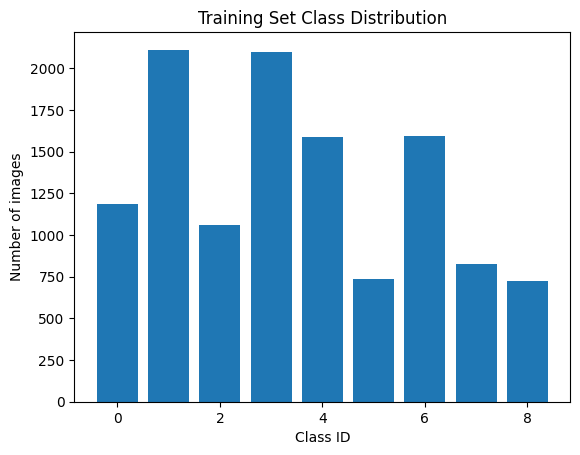

In [14]:
# to see if we have imbalance data
plt.bar(unique, counts)
plt.xlabel('Class ID')
plt.ylabel('Number of images')
plt.title('Training Set Class Distribution')
plt.show()

## **infrastructure class and traffic accidents class and water disaster class all of theme have lower percent of images compared to the other classes they also have the lowest accuracy among the other classes in the model final evaluation**

The next cell code ref  https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

In [15]:
# حل مشكلة عدم توازن الفئات بتعديل الاوزان

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))


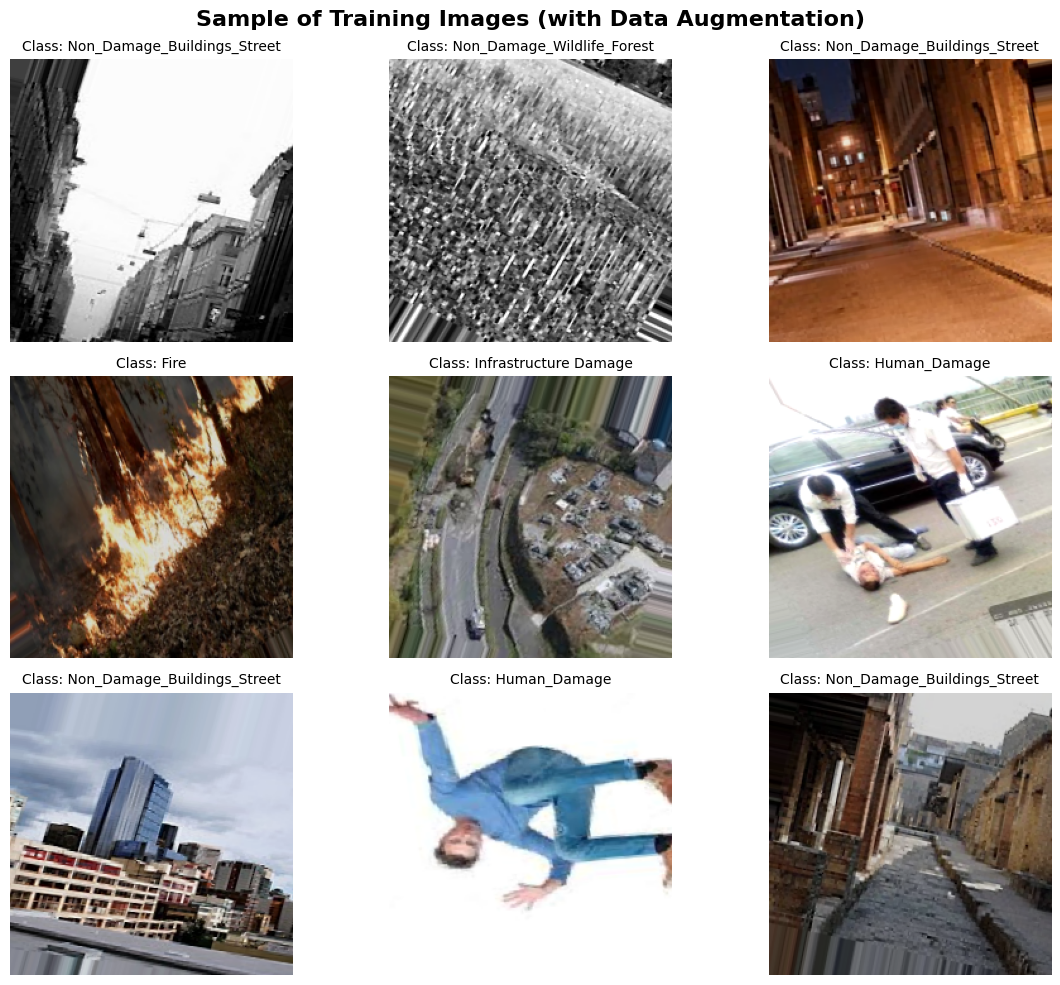

In [ ]:
# Display sample of training images (augmented)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Sample of Training Images (with Data Augmentation)', fontsize=16, fontweight='bold')

# Get a batch of training data
images, labels = next(train_generator)

# Plot 9 images
for i, (img, label) in enumerate(zip(images[:9], labels[:9])):
    ax = axes[i // 3, i % 3]

    # Convert image from numpy array to displayable format
    ax.imshow(img)

    # Get class name from one-hot encoded label
    class_idx = np.argmax(label)
    class_name = [k for k, v in train_generator.class_indices.items() if v == class_idx][0]

    ax.set_title(f'Class: {class_name}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


استعمالي للتالي
ImageDataGenerator و class_mode='categorical'
صار ما يحتاج اسوي ترميز لليبل كل صورة مثل الي برابط موقع geeks for geeks

1.   one-hot encoding للـ labels  
المولد يسويها تلقائي مثل الي موضح فوق
2.   ما احتجت اساسا يكون عندي اي متغير يخص الليبل مثل y_train أو y_test أو y_val
لان المولد يعرفها ويرجع كل صورة بالليبل حقها
3. ما احتجت احدد ال batch_Size في خطوات الموديل الجاية
المولد حددها مسبقا اساسا


**Building the CNN Model**
ref: https://www.geeksforgeeks.org/machine-learning/image-classifier-using-cnn/

**1) BASELINE CNN MODEL**

Now, we define the CNN architecture and start with convolutional layers followed by max-pooling layers, flatten the output and then feed it into fully connected layers.

Flatten Layer: Converts the 2D matrix into a 1D vector for the dense layers.
Dense Layers: Fully connected layers used for decision making, with the final layer using softmax activation to predict probabilities.

In [16]:
num_classes = train_generator.num_classes

In [ ]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

model = models.Sequential([
    # input shape is 224*224 and 3 because it's RGB (3 channels)
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    12,845,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,902,025 (49.22 MB)

 Trainable params: 12,902,025 (49.22 MB)

 Non-trainable params: 0 (0.00 B)

**Step ?: Compiling and Training the Model**

We then compile the model by defining the optimizer, loss function and evaluation metric, followed by training. SGD optimizer is used as it adjusts the learning rate during training.

مع model.fit
مايحتاج اعطيه التالي:
labels أو validation_split أو batch_size في model.fit
لاني مستعملة المولد

In [ ]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

opt = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=2)

Epoch 1/15
373/373 - 271s - 725ms/step - accuracy: 0.4294 - loss: 1.6463 - precision: 0.7393 - recall: 0.1791 - val_accuracy: 0.5714 - val_loss: 1.3466 - val_precision: 0.7765 - val_recall: 0.3264
Epoch 2/15
373/373 - 246s - 661ms/step - accuracy: 0.5310 - loss: 1.3625 - precision: 0.7391 - recall: 0.3244 - val_accuracy: 0.5922 - val_loss: 1.2682 - val_precision: 0.7629 - val_recall: 0.4384
Epoch 3/15
373/373 - 247s - 662ms/step - accuracy: 0.5629 - loss: 1.2782 - precision: 0.7484 - recall: 0.3685 - val_accuracy: 0.6102 - val_loss: 1.1693 - val_precision: 0.7306 - val_recall: 0.5022
Epoch 4/15
373/373 - 248s - 666ms/step - accuracy: 0.5885 - loss: 1.1949 - precision: 0.7593 - recall: 0.4180 - val_accuracy: 0.6427 - val_loss: 1.0890 - val_precision: 0.7874 - val_recall: 0.5072
Epoch 5/15
373/373 - 244s - 654ms/step - accuracy: 0.6102 - loss: 1.1364 - precision: 0.7731 - recall: 0.4517 - val_accuracy: 0.6164 - val_loss: 1.1236 - val_precision: 0.7637 - val_recall: 0.4947
Epoch 6/15
373/

In [ ]:
# Do not run this cell
import pickle
# we need to save the history4 variable to use it later when we load the model from the folder
with open('/content/drive/MyDrive/disaster-recognition-using-CNN/history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

# لحفظ النموذج
model.save('my_ver4_cnn_model.h5') # temp on colab ينحذف لما اقفل الجلسة
model.save('/content/drive/MyDrive/disaster-recognition-using-CNN/my_ver4_cnn_model.h5') # دائم على الدرايف

In [18]:
# to import the saved model later
# run this cell instead of the previous two cells

model = load_model('/content/drive/MyDrive/disaster-recognition-using-CNN/my_ver3_cnn_model.h5')

In [19]:
with open('/content/drive/MyDrive/disaster-recognition-using-CNN/history.pkl', 'rb') as f:
    history = pickle.load(f)

**Evaluating the Model**

After training, we evaluate the model on the test dataset to check how well it performs on unseen data.






ما يحتاج هنا اعطي الفنكشن y_test لاني استعملت المولد

**Accuracy**

In [20]:
def evaluate_model(model, test_generator):
    # التقييم
    results = model.evaluate(test_generator, verbose=2)
    print("Loss:", results[0])
    print("Accuracy:", results[1])
    print("Precision:", results[2])
    print("Recall:", results[3])

    # التوقعات
    y_pred_probs = model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes

    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    return results, cm, y_pred, y_true

In [21]:
def evaluate_entropy_and_plot(y_pred_probs):
    entropies = entropy(y_pred_probs, axis=1)
    print("Predictive Entropy (first 10 samples):\n", entropies[:10])
    print("Average Predictive Entropy:", np.mean(entropies))
    plt.figure(figsize=(8,5))
    plt.hist(entropies, bins=30, color='orange', edgecolor='black')
    plt.xlabel('Predictive Entropy')
    plt.ylabel('Count')
    plt.title('Uncertainty Distribution (Predictive Entropy)')
    plt.show()

In [22]:
results = model.evaluate(val_generator, verbose=2)
print("Loss:", results[0])
print("Accuracy:", results[1])
print("Precision:", results[2])
print("Recall:", results[3])

80/80 - 21s - 262ms/step - accuracy: 0.7436 - loss: 0.7870 - precision: 0.8368 - recall: 0.6544
Loss: 0.7870030403137207
Accuracy: 0.7436399459838867
Precision: 0.8368368148803711
Recall: 0.6544031500816345


**precision, recall, f1-score, confusion matrix:**

In [23]:
# مع انه المولد يعرفها تلقائيا وما كنا نحتاج نعرف بعض المتغيرات بشكل يدوي
# لكن الان نحتاجها عشان عمليات التقييم الاضافية المذكورة بالبروبوزال حقنا
# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
# Get true labels
y_true = test_generator.classes

80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step


In [24]:
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

           0       0.93      0.64      0.76       254
           1       0.90      0.65      0.76       453
           2       0.42      0.58      0.49       227
           3       0.76      0.79      0.77       451
           4       0.84      0.95      0.89       341
           5       0.76      0.66      0.70       159
           6       0.80      0.88      0.84       341
           7       0.43      0.60      0.50       178
           8       0.58      0.46      0.51       156

    accuracy                           0.72      2560
   macro avg       0.71      0.69      0.69      2560
weighted avg       0.75      0.72      0.73      2560

Confusion Matrix:
 [[162   3  25   7   6  10  23  10   8]
 [  2 296  28  35   3  22   6  48  13]
 [  2   1 132  14  15   1   3  47  12]
 [  2   0  38 356  25   0  19   7   4]
 [  0   0   8   4 324   0   2   1   2]
 [  5  18   8  13   0 105   1   4   5]
 [  1   0  16   9   7   1 301   4   2]
 [ 

**predictive entropy:**

In [ ]:
def mc_dropout_predict(model, x, n_iter=50):
    preds = [model(x, training=True).numpy() for _ in range(n_iter)]
    preds = np.array(preds)
    mean_preds = preds.mean(axis=0)
    std_preds = preds.std(axis=0)
    return mean_preds, std_preds

In [34]:
# الحصول على batch من بيانات الاختبار
batch_images, batch_labels = next(test_generator)

# استخدام MC Dropout للتنبؤ وعدم اليقين
mean_preds, std_preds = mc_dropout_predict(model, batch_images, n_iter=50)

# طباعة النتائج لأول صورة في الـ batch

class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(mean_preds[0])]
uncertainty = std_preds[0][np.argmax(mean_preds[0])]

print("Predicted Class:", predicted_class)
print("Uncertainty (Standard Deviation)", uncertainty)
print("Predictions Distribution:", mean_preds[0])
print("Uncertainty Distribution:", std_preds[0])

Predicted Class: Fire
Uncertainty (Standard Deviation) 2.9802322e-07
Predictions Distribution: [9.9966055e-01 8.9404217e-08 3.6074201e-07 1.3093701e-04 1.7698387e-05
 1.2091323e-06 1.8884486e-04 7.8225142e-09 3.0229906e-08]
Uncertainty Distribution: [2.9802322e-07 3.5527137e-14 2.8421709e-14 5.8207661e-11 3.6379788e-12
 5.6843419e-13 0.0000000e+00 2.6645353e-15 1.0658141e-14]


In [ ]:
uncertainties = np.max(std_preds, axis=1)


In [ ]:
# رسم توزيع الانحراف المعياري
plt.figure(figsize=(8,5))
plt.hist(uncertainties, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Max Std (Uncertainty)')
plt.ylabel('Count')
plt.title('Uncertainty Distribution (MC Dropout Std)')
plt.show()

In [37]:
ent1 = entropy(mean_preds, axis=1)
print("Predictive Entropy:", ent1)

Predictive Entropy: [0.0033467  0.04896359 1.1907619  1.6593022  1.6293726  1.6875045
 1.5447416  1.8345003  1.6720569  1.3125206  0.36034435 0.93043053
 1.3453019  1.5530005  1.4117578  1.045429   0.60564697 1.0284481
 0.50459385 1.8662833  1.6332477  0.07664291 0.54724735 0.97870076
 0.5825319  0.90552145 0.13277492 1.0771992  0.8808859  1.1657277
 1.388472   1.3785005 ]


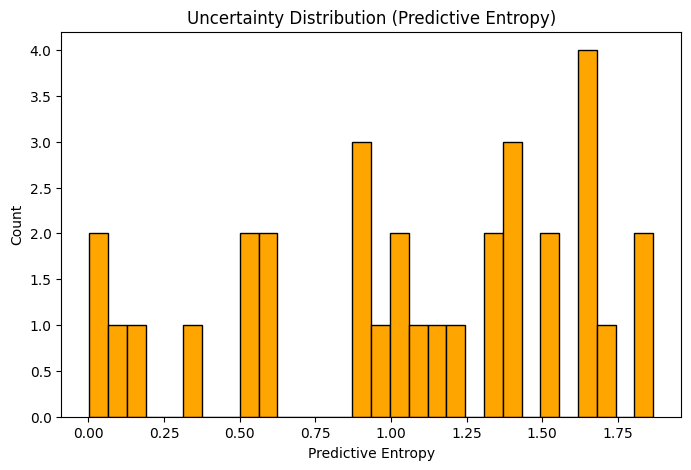

In [38]:
plt.figure(figsize=(8,5))
plt.hist(ent1, bins=30, color='orange', edgecolor='black')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.title('Uncertainty Distribution (Predictive Entropy)')
plt.show()

# **Plotting the evaluation metrics**


we visualize the training and validation accuracy during training using matplotlib.






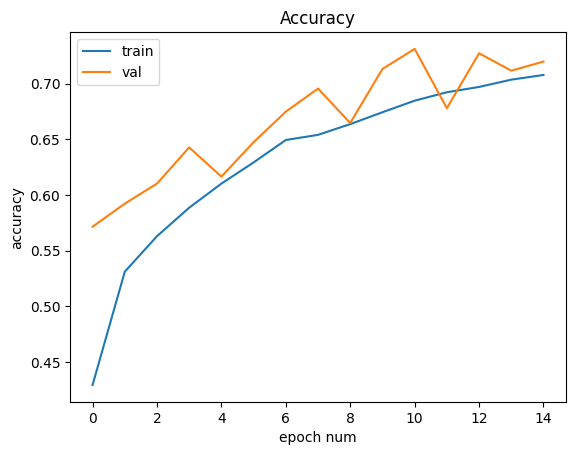

In [26]:
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.xlabel("epoch num")
plt.ylabel("accuracy")
plt.show()

visualize the confusion matrix

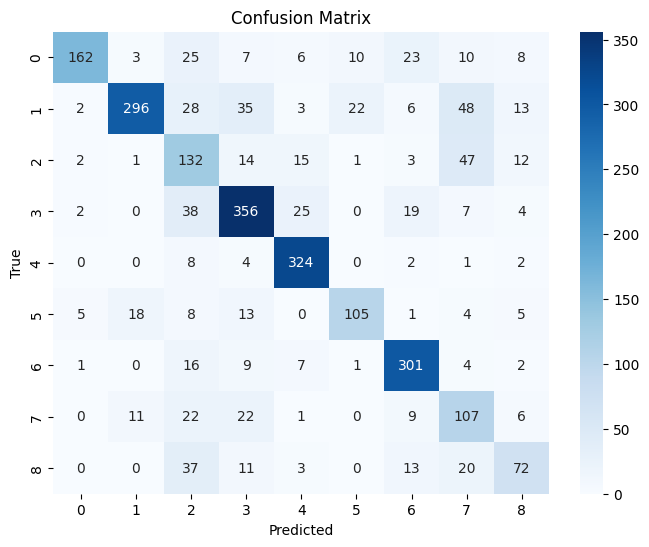

In [27]:

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

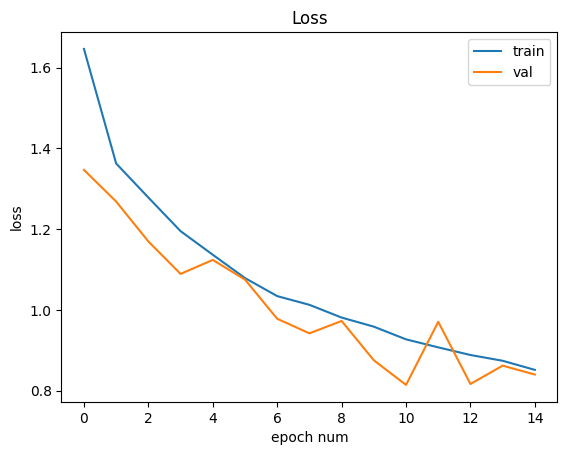

In [29]:
# سوي لها رن بالرن الجاي بعد ما اعدل الموديل
# رسم loss
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.legend()
plt.title('Loss')
plt.xlabel("epoch num")
plt.ylabel("loss")
plt.show()



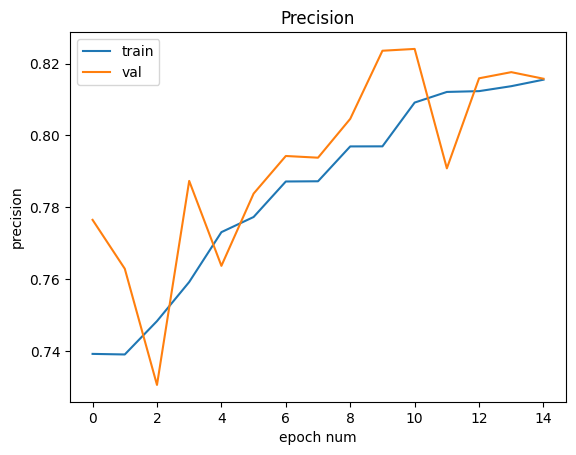

In [30]:
# رسم precision
plt.plot(history['precision'], label='train')
plt.plot(history['val_precision'], label='val')
plt.legend()
plt.title('Precision')
plt.xlabel("epoch num")
plt.ylabel("precision")
plt.show()



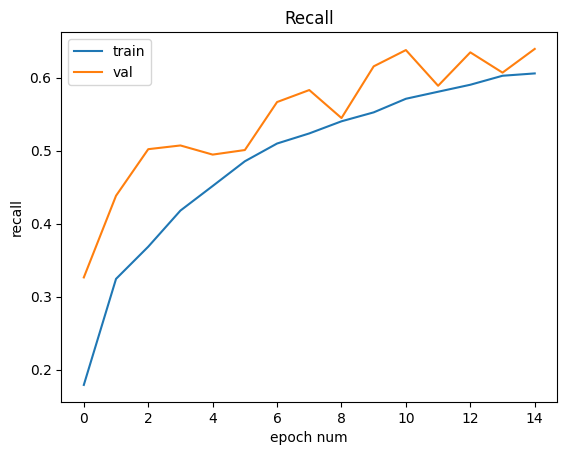

In [31]:
# رسم recall
plt.plot(history['recall'], label='train')
plt.plot(history['val_recall'], label='val')
plt.legend()
plt.title('Recall')
plt.xlabel("epoch num")
plt.ylabel("recall")
plt.show()

# **Sobel filter for edge detection + Attention Mechanism + CNN Model 2**

In [39]:

# Sobel filter layer
def sobel_layer(x):
    sobel_x = tf.image.sobel_edges(x)
    # sobel_x shape: (batch, h, w, channels, 2)  # 2: dx, dy

    sobel_mag = tf.sqrt(tf.reduce_sum(tf.square(sobel_x), axis=-1))
    return sobel_mag


In [40]:

# Attention block
def se_block(input_tensor, ratio=8):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    # se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(max(1, filters // ratio), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([input_tensor, se])


In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# حفظ أفضل نموذج تلقائيًا
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# **BUILDING CNN WITH SOBEL AND ATTENTION MECHANISM**


In [42]:
# dropout code from https://medium.com/@vishnuam/dropout-in-convolutional-neural-networks-cnn-422a4a17da41
# نموذج كامل
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

num_classes2 = 9
inputs = layers.Input(shape=(224, 224, 3))
# 1. Sobel
sobel = layers.Lambda(sobel_layer)(inputs)
# 2. Attention
attention = se_block(sobel)
# 3. CNN
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(attention)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Dropout(0.25)(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation='relu')(x)
x= layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes2, activation='softmax')(x)

model_adv = models.Model(inputs, outputs)
model_adv.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 3)         │          0 │ lambda[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          4 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │          6 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 3)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ lambda[0][0],     │
│                     │ 3)                │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ multiply[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100352)    │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │  3,211,296 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │        297 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,221,747 (12.29 MB)

 Trainable params: 3,221,747 (12.29 MB)

 Non-trainable params: 0 (0.00 B)

# **COMPILE AND TRAIN THE MODEL**

In [ ]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

#from tensorflow.keras.optimizers import SGD
opt = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
model_adv.compile(optimizer=opt, #instead of 'adam'
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

history2 = model_adv.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights,
    verbose=2)

Epoch 1/15

Epoch 1: val_loss improved from None to 1.78682, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
373/373 - 288s - 772ms/step - accuracy: 0.2480 - loss: 2.0372 - precision_1: 0.6271 - recall_1: 0.0155 - val_accuracy: 0.3961 - val_loss: 1.7868 - val_precision_1: 0.6867 - val_recall_1: 0.0892
Epoch 2/15

Epoch 2: val_loss improved from 1.78682 to 1.59416, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
373/373 - 237s - 636ms/step - accuracy: 0.3507 - loss: 1.8203 - precision_1: 0.6974 - recall_1: 0.0812 - val_accuracy: 0.4333 - val_loss: 1.5942 - val_precision_1: 0.7841 - val_recall_1: 0.1620
Epoch 3/15

Epoch 3: val_loss improved from 1.59416 to 1.47416, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
373/373 - 240s - 644ms/step - accuracy: 0.3888 - loss: 1.7169 - precision_1: 0.7021 - recall_1: 0.1212 - val_accuracy: 0.5237 - val_loss: 1.4742 - val_precision_1: 0.8239 - val_recall_1: 0.1483
Epoch 4/15

Epoch 4: val_loss improved from 1.47416 to 1.45189, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
373/373 - 236s - 633ms/step - accuracy: 0.4195 - loss: 1.6390 - precision_1: 0.7204 - recall_1: 0.1560 - val_accuracy: 0.5065 - val_loss: 1.4519 - val_precision_1: 0.7694 - val_recall_1: 0.1632
Epoch 5/15

Epoch 5: val_loss improved from 1.45189 to 1.34275, saving model to best_model.h5


...


Epoch 8: finished saving model to best_model.h5
373/373 - 239s - 642ms/step - accuracy: 0.4904 - loss: 1.4802 - precision_1: 0.7494 - recall_1: 0.2409 - val_accuracy: 0.6070 - val_loss: 1.2018 - val_precision_1: 0.8529 - val_recall_1: 0.3382
Epoch 9/15

Epoch 9: val_loss did not improve from 1.20181
373/373 - 241s - 646ms/step - accuracy: 0.5078 - loss: 1.4456 - precision_1: 0.7486 - recall_1: 0.2663 - val_accuracy: 0.6129 - val_loss: 1.2270 - val_precision_1: 0.8509 - val_recall_1: 0.3194
Epoch 10/15

Epoch 10: val_loss improved from 1.20181 to 1.19645, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
373/373 - 241s - 645ms/step - accuracy: 0.5176 - loss: 1.4096 - precision_1: 0.7621 - recall_1: 0.2779 - val_accuracy: 0.6059 - val_loss: 1.1964 - val_precision_1: 0.8423 - val_recall_1: 0.3386
Epoch 11/15

Epoch 11: val_loss improved from 1.19645 to 1.18138, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
373/373 - 238s - 639ms/step - accuracy: 0.5276 - loss: 1.3977 - precision_1: 0.7617 - recall_1: 0.2896 - val_accuracy: 0.6227 - val_loss: 1.1814 - val_precision_1: 0.8438 - val_recall_1: 0.3405
Epoch 12/15

Epoch 12: val_loss did not improve from 1.18138
373/373 - 237s - 635ms/step - accuracy: 0.5284 - loss: 1.3937 - precision_1: 0.7657 - recall_1: 0.2963 - val_accuracy: 0.5710 - val_loss: 1.2319 - val_precision_1: 0.7710 - val_recall_1: 0.3624
Epoch 13/15

Epoch 13: val_loss improved from 1.18138 to 1.12269, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
373/373 - 233s - 623ms/step - accuracy: 0.5320 - loss: 1.3785 - precision_1: 0.7682 - recall_1: 0.2997 - val_accuracy: 0.6348 - val_loss: 1.1227 - val_precision_1: 0.8629 - val_recall_1: 0.3867
Epoch 14/15

Epoch 14: val_loss improved from 1.12269 to 1.08648, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
373/373 - 235s - 631ms/step - accuracy: 0.5418 - loss: 1.3599 - precision_1: 0.7693 - recall_1: 0.3162 - val_accuracy: 0.6403 - val_loss: 1.0865 - val_precision_1: 0.8469 - val_recall_1: 0.4329
Epoch 15/15

Epoch 15: val_loss did not improve from 1.08648
373/373 - 235s - 629ms/step - accuracy: 0.5466 - loss: 1.3454 - precision_1: 0.7695 - recall_1: 0.3248 - val_accuracy: 0.6485 - val_loss: 1.1008 - val_precision_1: 0.8546 - val_recall_1: 0.4117
Restoring model weights from the end of the best epoch: 14.


# **SAVE THE MODEL IN DRIVE FOR AN EASY REUSE**


In [ ]:
import pickle
# we need to save the history4 variable to use it later when we load the model from the folder
with open('/content/drive/MyDrive/disaster-recognition-using-CNN/history2.pkl', 'wb') as f:
    pickle.dump(history2.history, f)

In [ ]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

model_adv.save('my_ver4_adv_cnn_withdrouput_earlystopping_sgd_model.h5') # temp on colab ينحذف لما اقفل الجلسة
model_adv.save('/content/drive/MyDrive/disaster-recognition-using-CNN/my_ver4_adv_cnn_withdrouput_earlystopping_sgd_model.h5') # دائم على الدرايف

**I TRAINED THE MODEL AND SAVE IT IN DRIVE, SO INSTEAD OF RUNNING THE ABOVE CELL
JUST LOAD THE MODEL FROM BELOW**

In [43]:
# to import the saved model later
model_adv = load_model('/content/drive/MyDrive/disaster-recognition-using-CNN/my_ver4_adv_cnn_withdrouput_earlystopping_sgd_model.h5', custom_objects={
        'sobel_layer': sobel_layer,
        'se_block': se_block
    })

In [44]:
with open('/content/drive/MyDrive/disaster-recognition-using-CNN/history2.pkl', 'rb') as f:
    history2 = pickle.load(f)

# **EVALUTE THE MODEL PERFORMANCE**

In [45]:
results2 = model_adv.evaluate(val_generator, verbose=2)
print("Loss:", results2[0])
print("Accuracy:", results2[1])
print("Precision:", results2[2])
print("Recall:", results2[3])

80/80 - 20s - 250ms/step - accuracy: 0.6607 - loss: 1.0530 - precision_1: 0.8500 - recall_1: 0.4548
Loss: 1.053004264831543
Accuracy: 0.6606653332710266
Precision: 0.8500365614891052
Recall: 0.4547945261001587


In [46]:
# مع انه المولد يعرفها تلقائيا وما كنا نحتاج نعرف بعض المتغيرات بشكل يدوي
# لكن الان نحتاجها عشان عمليات التقييم الاضافية المذكورة بالبروبوزال حقنا
# Get predictions
y_pred_probs2 = model_adv.predict(test_generator)
y_pred2 = np.argmax(y_pred_probs2, axis=1)
# Get true labels
y_true2 = test_generator.classes

80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step


In [47]:
print(classification_report(y_true2, y_pred2))
cm2 = confusion_matrix(y_true2, y_pred2)
print("Confusion Matrix:\n", cm2)

              precision    recall  f1-score   support

           0       0.92      0.63      0.74       254
           1       0.72      0.64      0.68       453
           2       0.46      0.20      0.28       227
           3       0.61      0.74      0.67       451
           4       0.71      0.91      0.80       341
           5       0.57      0.50      0.53       159
           6       0.71      0.83      0.77       341
           7       0.47      0.40      0.43       178
           8       0.30      0.42      0.35       156

    accuracy                           0.64      2560
   macro avg       0.61      0.58      0.58      2560
weighted avg       0.64      0.64      0.63      2560

Confusion Matrix:
 [[159  17   6  15   9  14  23   2   9]
 [  2 291   6  42   8  34  12  33  25]
 [  3   3  45  75  43   2  16  10  30]
 [  3  20  14 332  24   6  16  12  24]
 [  0   1   3  19 311   0   2   4   1]
 [  3  46   1   5   1  79   8   6  10]
 [  3   2   7  10   6   1 283   3  26]
 [ 

# **PLOTTING THE EVALUATION RESULTS**

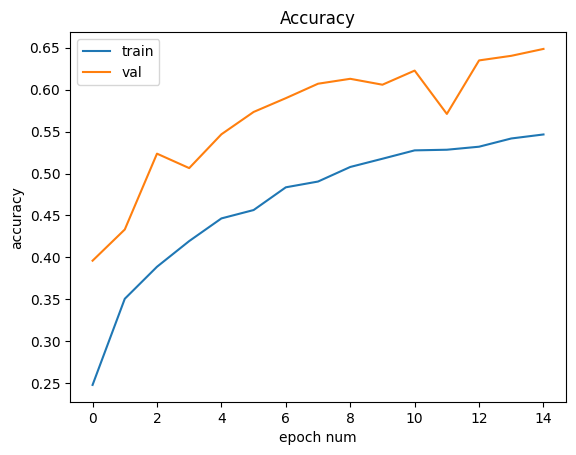

In [48]:
plt.plot(history2['accuracy'], label='train')
plt.plot(history2['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.xlabel("epoch num")
plt.ylabel("accuracy")
plt.show()

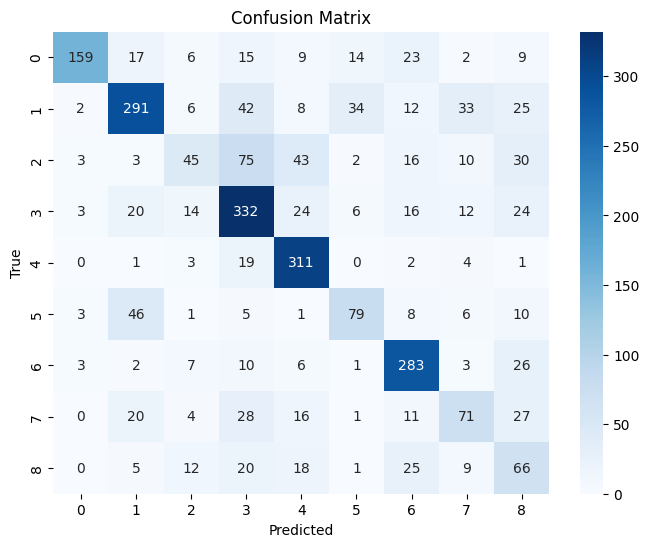

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

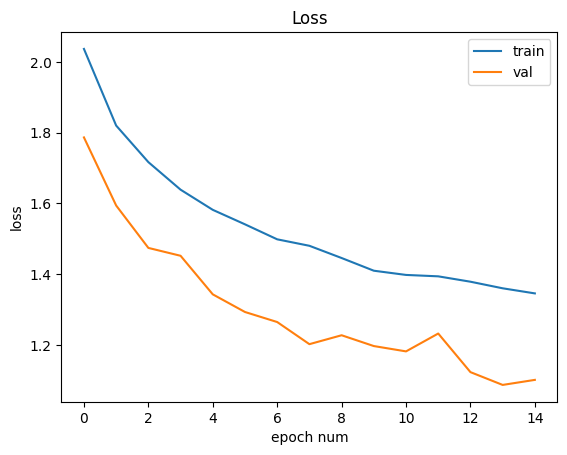

In [50]:
# رسم loss
plt.plot(history2['loss'], label='train')
plt.plot(history2['val_loss'], label='val')
plt.legend()
plt.title('Loss')
plt.xlabel("epoch num")
plt.ylabel("loss")
plt.show()



In [54]:
print(history2.keys())

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1'])


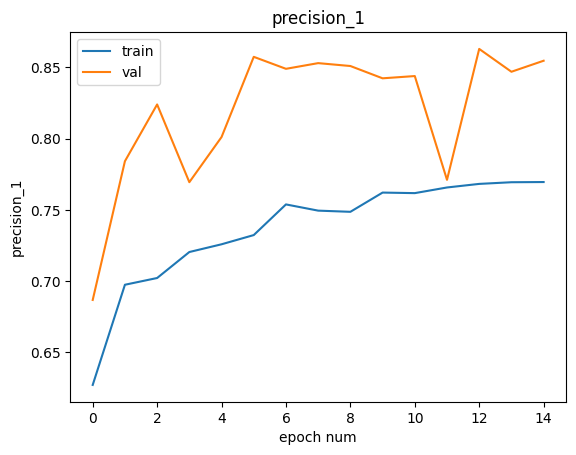

In [55]:
# رسم precision
plt.plot(history2['precision_1'], label='train')
plt.plot(history2['val_precision_1'], label='val')
plt.legend()
plt.title('precision_1')
plt.xlabel("epoch num")
plt.ylabel("precision_1")
plt.show()

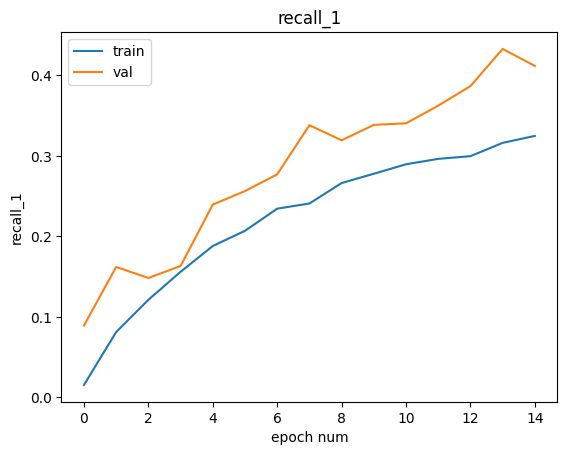

In [56]:
# رسم recall
plt.plot(history2['recall_1'], label='train')
plt.plot(history2['val_recall_1'], label='val')
plt.legend()
plt.title('recall_1')
plt.xlabel("epoch num")
plt.ylabel("recall_1")
plt.show()

In [57]:
def mc_dropout_predict(model, x, n_iter=50):
    preds = [model(x, training=True).numpy() for _ in range(n_iter)]
    preds = np.array(preds)
    mean_preds = preds.mean(axis=0)
    std_preds = preds.std(axis=0)
    return mean_preds, std_preds

In [58]:
# الحصول على batch من بيانات الاختبار
batch_images, batch_labels = next(test_generator)

# استخدام MC Dropout للتنبؤ وعدم اليقين
mean_preds, std_preds = mc_dropout_predict(model_adv, batch_images, n_iter=50)

# طباعة النتائج لأول صورة في الـ batch

class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(mean_preds[0])]
uncertainty = std_preds[0][np.argmax(mean_preds[0])]

print("Predicted Class:", predicted_class)
print("Uncertainty (Standard Deviation)", uncertainty)
print("Predictions Distribution:", mean_preds[0])
print("Uncertainty Distribution:", std_preds[0])

Predicted Class: Non_Damage_human
Uncertainty (Standard Deviation) 0.18717678
Predictions Distribution: [1.5372723e-01 5.1066142e-02 1.0250099e-02 8.7514976e-03 1.6503460e-03
 7.5972795e-01 7.4392511e-04 1.1878040e-02 2.2047379e-03]
Uncertainty Distribution: [0.15850778 0.05804868 0.03686295 0.02674476 0.00711309 0.18717678
 0.00197104 0.03300858 0.00716541]


In [ ]:
uncertainties = np.max(std_preds, axis=1)


In [ ]:
# رسم توزيع الانحراف المعياري
plt.figure(figsize=(8,5))
plt.hist(uncertainties, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Max Std (Uncertainty)')
plt.ylabel('Count')
plt.title('Uncertainty Distribution (MC Dropout Std)')
plt.show()

In [59]:
ent = entropy(mean_preds, axis=1)
print("Predictive Entropy:", ent)

Predictive Entropy: [0.8190328 2.0321913 1.1190282 1.1777349 2.0634632 1.6361854 1.6116905
 1.8929689 1.8460214 2.0647495 1.3343489 1.2294931 2.1148522 1.9183221
 1.1715635 1.742116  1.8953092 2.0530686 2.105575  1.6754477 1.8642377
 1.9553443 1.4615909 1.2138014 1.5654196 1.0191536 1.7027512 1.6359928
 1.632758  1.9906342 1.8004714 0.5129484]


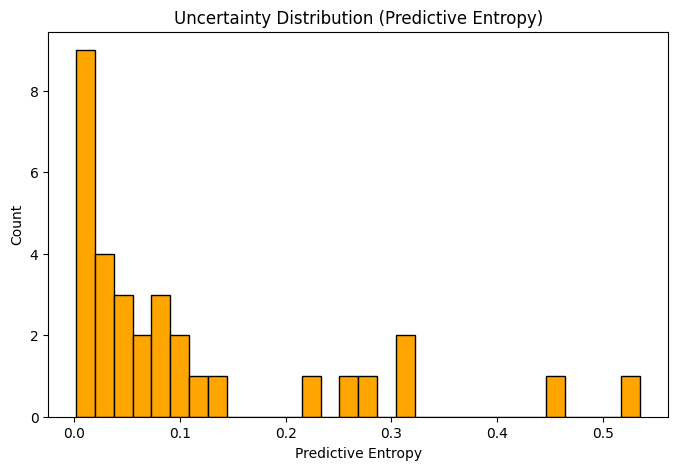

In [121]:
plt.figure(figsize=(8,5))
plt.hist(ent, bins=30, color='orange', edgecolor='black')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.title('Uncertainty Distribution (Predictive Entropy)')
plt.show()

# **ADVANCED MODEL USING FEATURE MERGING:**

In [63]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder
inputs = layers.Input(shape=(224, 224, 3))

# MobileNetV2
mobilenet_base = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', pooling='avg'
)
mobilenet_base.trainable = False
features_mobilenet = mobilenet_base(inputs)

# DenseNet121
densenet_base = tf.keras.applications.DenseNet121(
    include_top=False, weights='imagenet', pooling='avg'
)
densenet_base.trainable = False
features_densenet = densenet_base(inputs)

# دمج الميزات
merged = layers.Concatenate()([features_mobilenet, features_densenet])

# طبقة الإخراج
x = layers.Dense(64, activation='relu')(merged)
x = layers.Dropout(0.3)(x)
outputs3 = layers.Dense(num_classes, activation='softmax')(x)

model_fusion = models.Model(inputs=inputs, outputs=outputs3)
model_fusion.summary()

/tmp/ipykernel_1167/2406600193.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 1024)      │  7,037,504 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2304)      │          0 │ mobilenetv2_1.00… │
│ (Concatenate)       │                   │            │ densenet121[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │    147,520 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 9)         │        585 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,443,593 (36.02 MB)

 Trainable params: 148,105 (578.54 KB)

 Non-trainable params: 9,295,488 (35.46 MB)

In [64]:
print("MobileNetV2 trainable:", mobilenet_base.trainable)
print("DenseNet121 trainable:", densenet_base.trainable)

MobileNetV2 trainable: False
DenseNet121 trainable: False


In [65]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder
opt = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
model_fusion.compile(optimizer=opt, #instead of 'adam'
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

history4 = model_fusion.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights,
    verbose=2)

Epoch 1/15

Epoch 1: val_loss improved from None to 0.41297, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
373/373 - 412s - 1s/step - accuracy: 0.7052 - loss: 0.9617 - precision: 0.8689 - recall: 0.5605 - val_accuracy: 0.8728 - val_loss: 0.4130 - val_precision: 0.9275 - val_recall: 0.8160
Epoch 2/15

Epoch 2: val_loss improved from 0.41297 to 0.33154, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
373/373 - 269s - 720ms/step - accuracy: 0.8344 - loss: 0.5605 - precision: 0.8938 - recall: 0.7747 - val_accuracy: 0.8986 - val_loss: 0.3315 - val_precision: 0.9330 - val_recall: 0.8614
Epoch 3/15

Epoch 3: val_loss improved from 0.33154 to 0.31038, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
373/373 - 274s - 735ms/step - accuracy: 0.8597 - loss: 0.4820 - precision: 0.9038 - recall: 0.8119 - val_accuracy: 0.9033 - val_loss: 0.3104 - val_precision: 0.9319 - val_recall: 0.8779
Epoch 4/15

Epoch 4: val_loss improved from 0.31038 to 0.27132, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
373/373 - 271s - 727ms/step - accuracy: 0.8726 - loss: 0.4373 - precision: 0.9139 - recall: 0.8311 - val_accuracy: 0.9155 - val_loss: 0.2713 - val_precision: 0.9345 - val_recall: 0.8932
Epoch 5/15

Epoch 5: val_loss did not improve from 0.27132
373/373 - 271s - 727ms/step - accuracy: 0.8793 - loss: 0.4009 - precision: 0.9195 - recall: 0.8457 - val_accuracy: 0.9010 - val_loss: 0.3101 - val_precision: 0.9256 - val_recall: 0.8818
Epoch 6/15

Epoch 6: val_loss did not improve from 0.27132
373/373 - 270s - 725ms/step - accuracy: 0.8832 - loss: 0.3897 - precision: 0.9195 - recall: 0.8514 - val_accuracy: 0.9104 - val_loss: 0.2909 - val_precision: 0.9249 - val_recall: 0.8916
Epoch 7/15

Epoch 7: val_loss improved from 0.27132 to 0.24927, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
373/373 - 274s - 734ms/step - accuracy: 0.8948 - loss: 0.3644 - precision: 0.9242 - recall: 0.8663 - val_accuracy: 0.9237 - val_loss: 0.2493 - val_precision: 0.9397 - val_recall: 0.9088
Epoch 8/15

Epoch 8: val_loss did not improve from 0.24927
373/373 - 270s - 725ms/step - accuracy: 0.8945 - loss: 0.3668 - precision: 0.9249 - recall: 0.8611 - val_accuracy: 0.9139 - val_loss: 0.2687 - val_precision: 0.9290 - val_recall: 0.9010
Epoch 9/15

Epoch 9: val_loss did not improve from 0.24927
373/373 - 268s - 718ms/step - accuracy: 0.9002 - loss: 0.3461 - precision: 0.9266 - recall: 0.8722 - val_accuracy: 0.9018 - val_loss: 0.3047 - val_precision: 0.9245 - val_recall: 0.8861
Epoch 10/15

Epoch 10: val_loss did not improve from 0.24927
373/373 - 269s - 721ms/step - accuracy: 0.9004 - loss: 0.3374 - precision: 0.9285 - recall: 0.8720 - val_accuracy: 0.9139 - val_loss: 0.2718 - val_precision: 0.9293 - val_recall: 0.9006
Epoch 11/15

Epoch 11: val_l

# **SAVE AND LOAD THE MODEL AND HISORY VARIABLE FROM DRIVE FOLDER**

In [66]:
import pickle
# we need to save the history4 variable to use it later when we load the model from the folder
with open('/content/drive/MyDrive/disaster-recognition-using-CNN/history4.pkl', 'wb') as f:
    pickle.dump(history4.history, f)

In [67]:
# Do not rerun this cell instead use the cell that load the saved model from the shared drive folder

# لحفظ النموذج
model_fusion.save('my_model_fusionV2.h5') # temp on colab ينحذف لما اقفل الجلسة
model_fusion.save('/content/drive/MyDrive/disaster-recognition-using-CNN/my_model_fusionV2.h5') # دائم على الدرايف

In [61]:
# to import the saved model later instead of redoing the previous cell of training the model
# load this cell instead
model_fusion = load_model('/content/drive/MyDrive/disaster-recognition-using-CNN/my_model_fusionV2.h5')

In [68]:
with open('/content/drive/MyDrive/disaster-recognition-using-CNN/history4.pkl', 'rb') as f:
    history4 = pickle.load(f)

# **VISUALIZE THE FUSION MODEL**

In [119]:
!apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


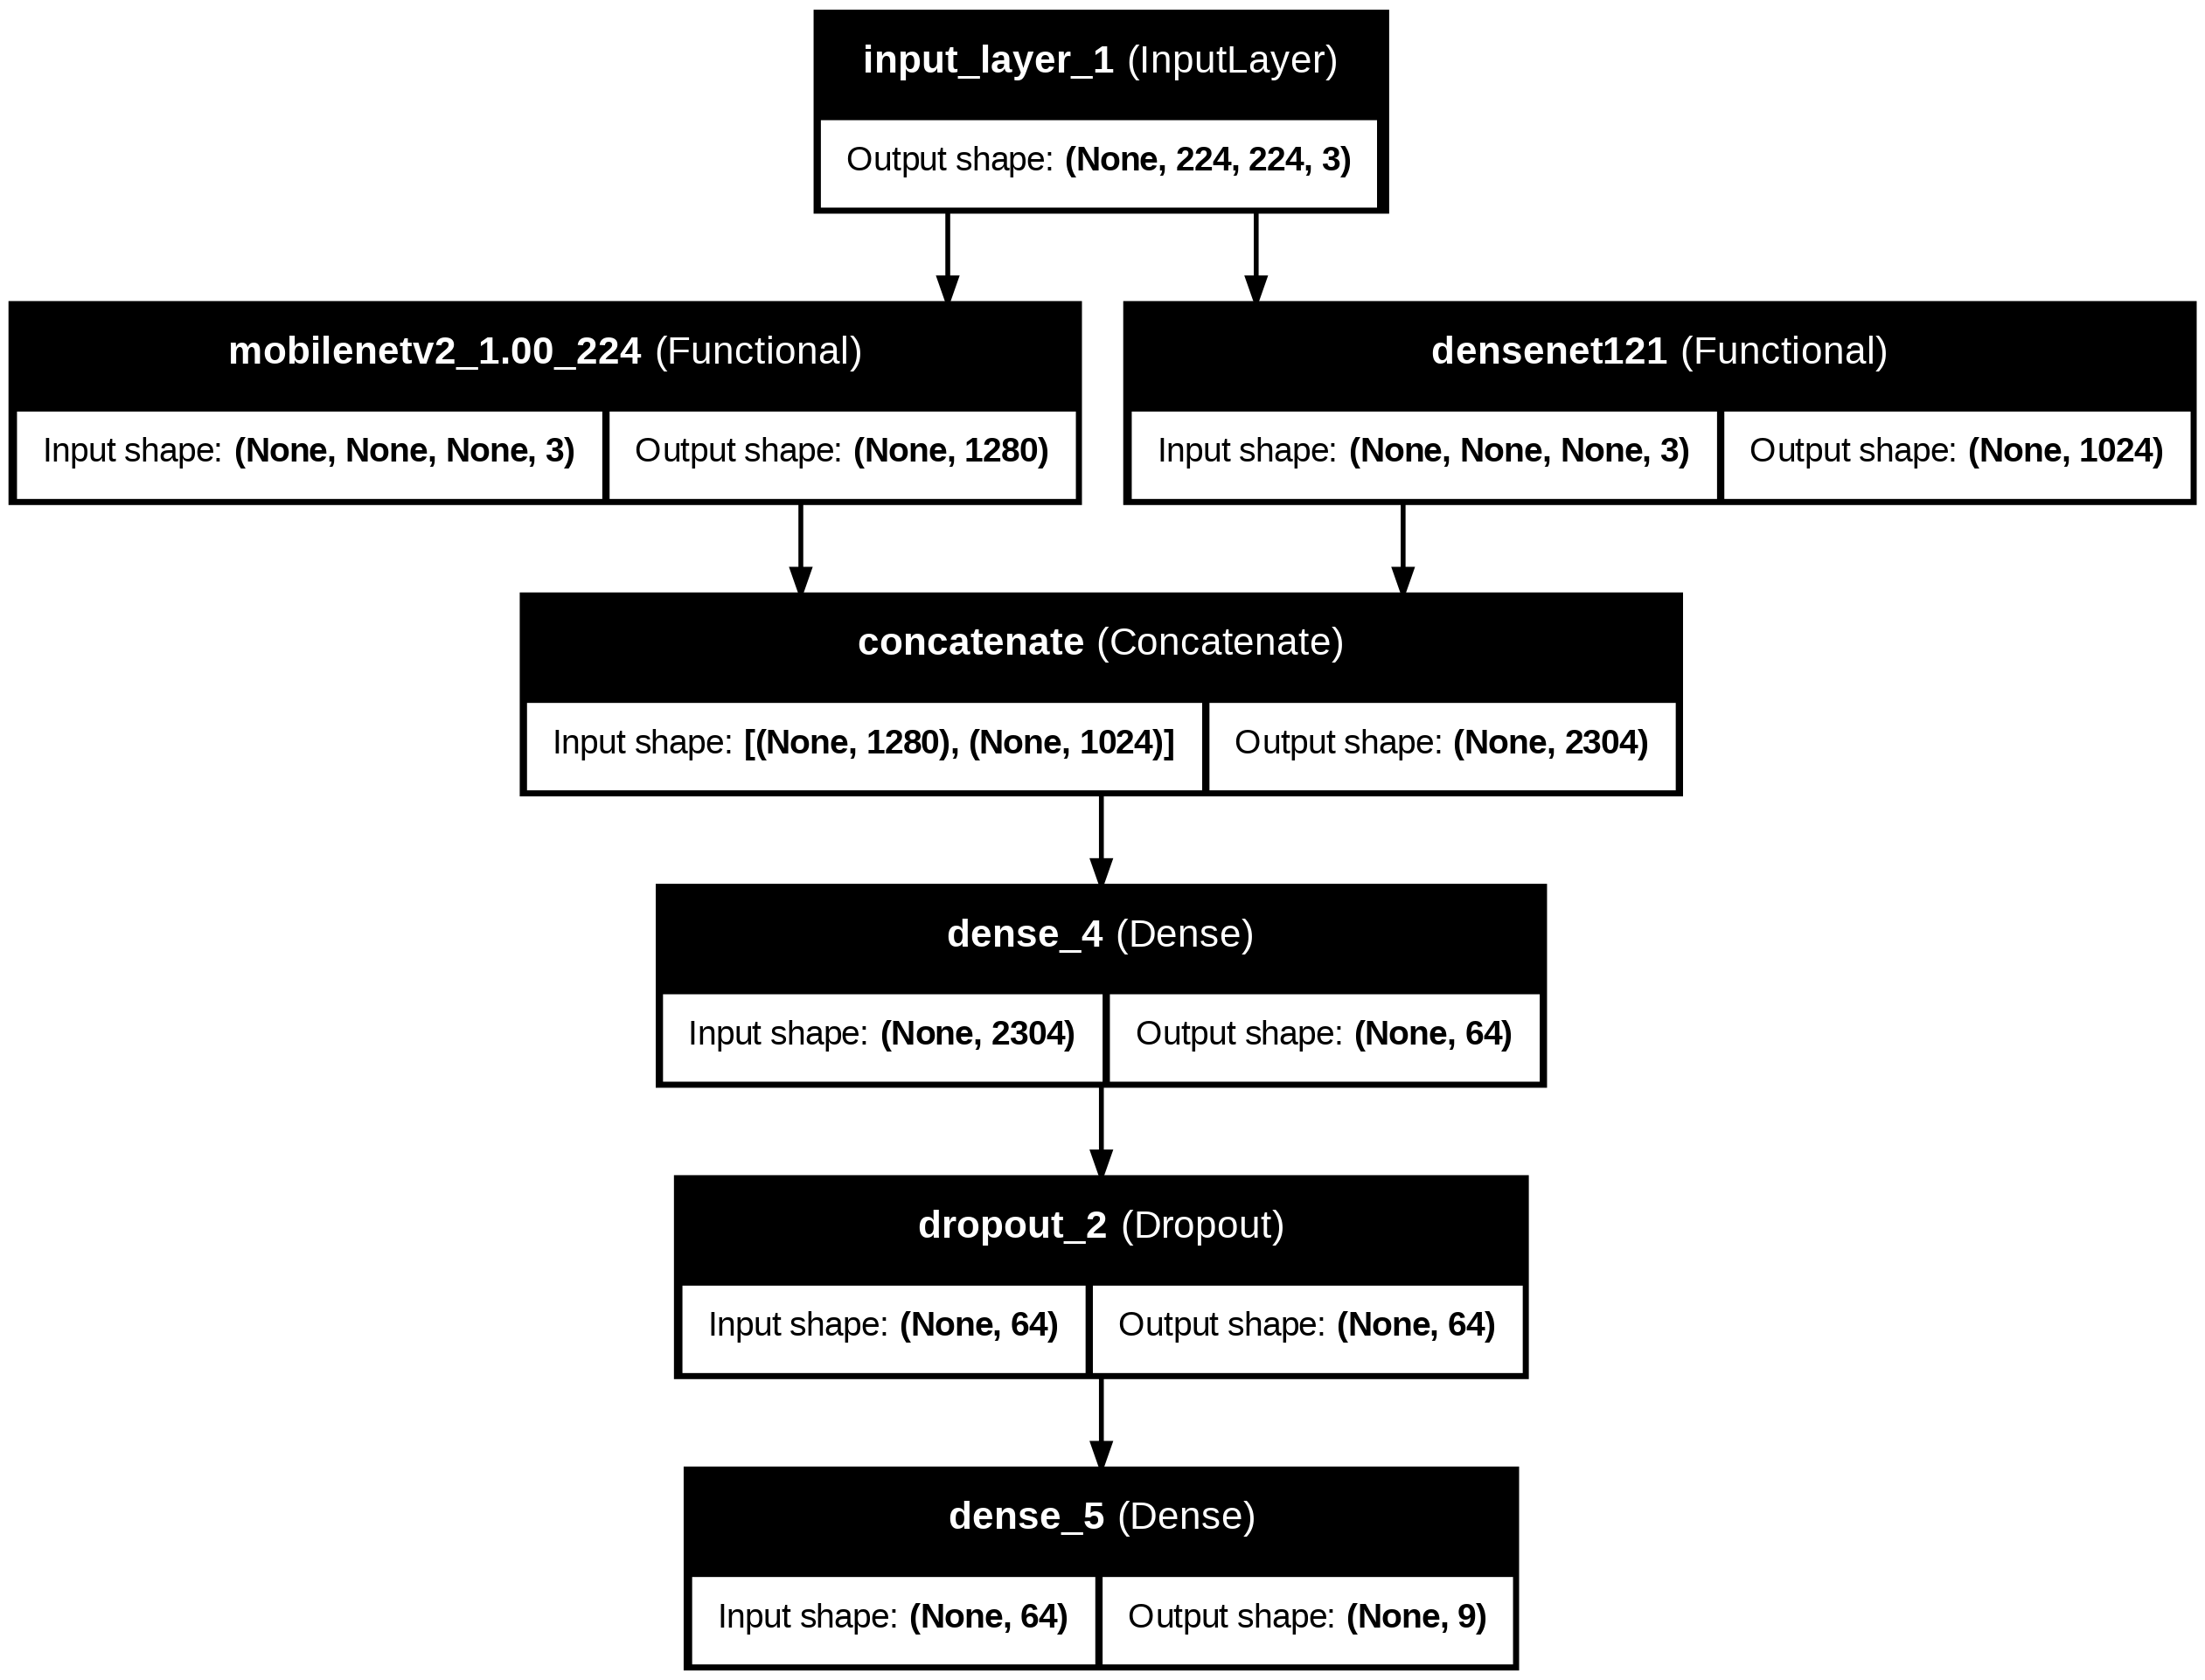

In [120]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# رسم النموذج وحفظه كصورة
plot_model(model_fusion, to_file='model.png', show_shapes=True, show_layer_names=True)

# عرض الصورة داخل الدفتر
Image(filename='model.png')

# **Model evaluation**

In [69]:
results3 = model_fusion.evaluate(val_generator, verbose=2)
print("Loss:",results3[0])
print("Accuracy:",results3[1])
print("Precision:",results3[2])
print("Recall:",results3[3])

80/80 - 22s - 280ms/step - accuracy: 0.9237 - loss: 0.2493 - precision: 0.9397 - recall: 0.9088
Loss: 0.24926944077014923
Accuracy: 0.9236790537834167
Precision: 0.9397005438804626
Recall: 0.9088062644004822


In [70]:
# Get predictions
y_pred_probs3 = model_fusion.predict(test_generator)
y_pred3 = np.argmax(y_pred_probs3, axis=1)
# Get true labels
y_true3 = test_generator.classes

80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 238ms/step


In [71]:
print(classification_report(y_true3, y_pred3))
cm3 = confusion_matrix(y_true3, y_pred3)
print("Confusion Matrix:\n", cm3)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94       254
           1       0.98      0.86      0.92       453
           2       0.73      0.84      0.78       227
           3       0.98      0.96      0.97       451
           4       0.99      0.97      0.98       341
           5       0.91      1.00      0.95       159
           6       0.98      0.93      0.95       341
           7       0.79      0.93      0.86       178
           8       0.68      0.81      0.74       156

    accuracy                           0.92      2560
   macro avg       0.89      0.91      0.90      2560
weighted avg       0.92      0.92      0.92      2560

Confusion Matrix:
 [[231   0  11   1   2   0   1   3   5]
 [  2 389  12   0   0  15   2  22  11]
 [  0   1 191   0   0   0   0  16  19]
 [  0   1  12 433   0   0   0   0   5]
 [  1   0   5   2 331   0   0   0   2]
 [  0   0   0   0   0 159   0   0   0]
 [  1   1   4   3   2   0 317   0  13]
 [ 

# **PLOT THE RESULTS**

In [72]:
print(history4.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


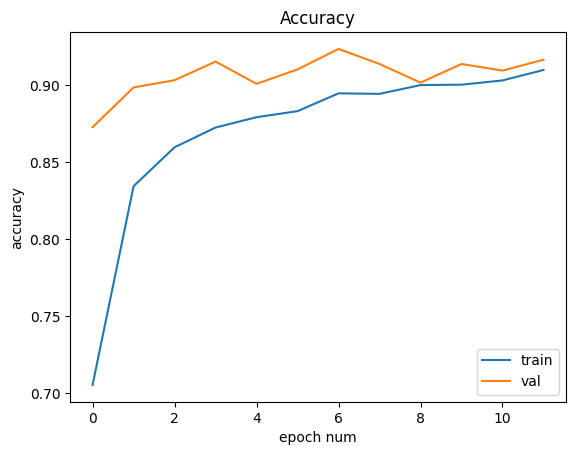

In [77]:
plt.plot(history4['accuracy'], label='train')
plt.plot(history4['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.xlabel("epoch num")
plt.ylabel("accuracy")
plt.show()

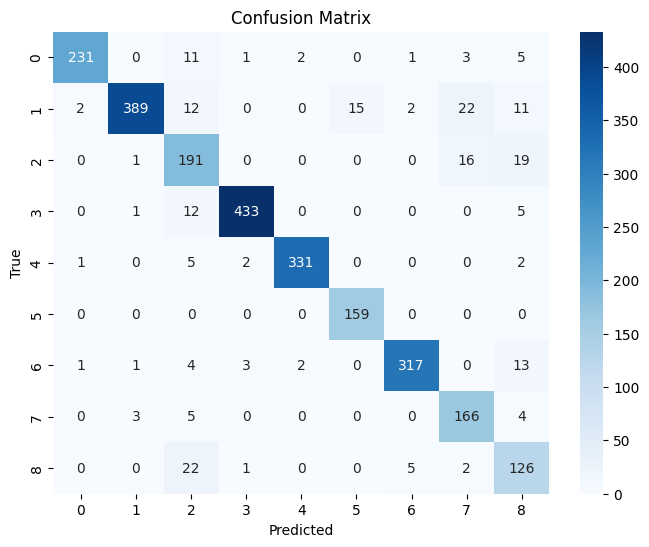

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

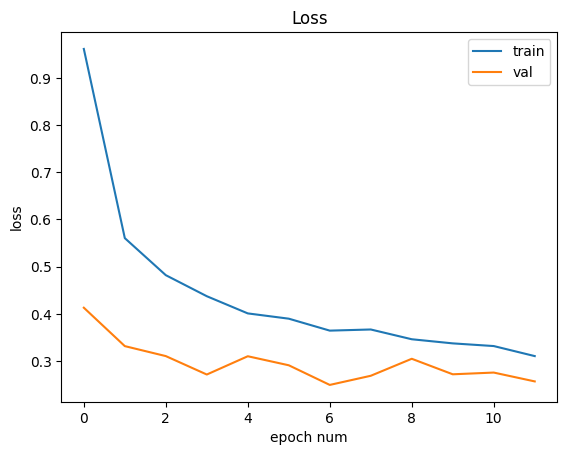

In [74]:
plt.plot(history4['loss'], label='train')
plt.plot(history4['val_loss'], label='val')
plt.legend()
plt.title('Loss')
plt.xlabel("epoch num")
plt.ylabel("loss")
plt.show()


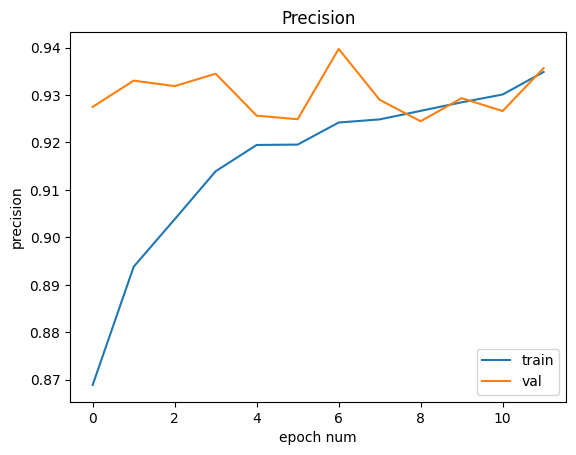

In [75]:
plt.plot(history4['precision'], label='train')
plt.plot(history4['val_precision'], label='val')
plt.legend()
plt.title('Precision')
plt.xlabel("epoch num")
plt.ylabel("precision")
plt.show()

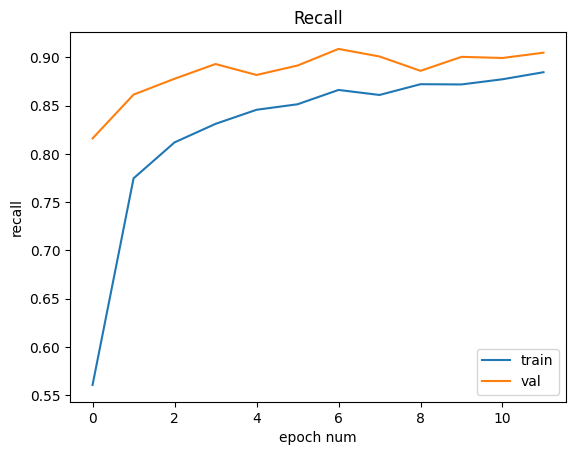

In [76]:
# رسم recall
plt.plot(history4['recall'], label='train')
plt.plot(history4['val_recall'], label='val')
plt.legend()
plt.title('Recall')
plt.xlabel("epoch num")
plt.ylabel("recall")
plt.show()

# **USING THE MODEL TO PREDICT ON UNSEEN IMAGE THEN CALCULATE THE UNCERTAINTY AND CLASS PROBABILITY**

In [112]:
def mc_dropout_predict(model, x, n_iter=50):
    preds = [model(x, training=True).numpy() for _ in range(n_iter)]
    preds = np.array(preds)
    mean_preds = preds.mean(axis=0)
    std_preds = preds.std(axis=0)
    return mean_preds, std_preds



In [113]:
# take some test data
batch_images, batch_labels = next(test_generator)

# predict and measure the uncertainty
mean_preds, std_preds = mc_dropout_predict(model_fusion, batch_images, n_iter=50)

# result for the Case Studies section

class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(mean_preds[4])]
uncertainty = std_preds[4][np.argmax(mean_preds[4])]

print("Predicted Class:", predicted_class)
print("Uncertainty (Standard Deviation)", uncertainty)
print("Predictions Distribution:", mean_preds[4])
print("Uncertainty Distribution:", std_preds[4])

Predicted Class: Fire
Uncertainty (Standard Deviation) 0.0092979865
Predictions Distribution: [9.9812436e-01 4.0744828e-05 9.5386822e-05 2.1710893e-04 1.0557761e-03
 1.4933584e-04 5.0659335e-05 1.9726226e-04 6.9414469e-05]
Uncertainty Distribution: [0.00929799 0.00017458 0.00036831 0.00124731 0.00616968 0.00053167
 0.00017234 0.00126579 0.0003613 ]


In [114]:
uncertainties = np.max(std_preds, axis=1)


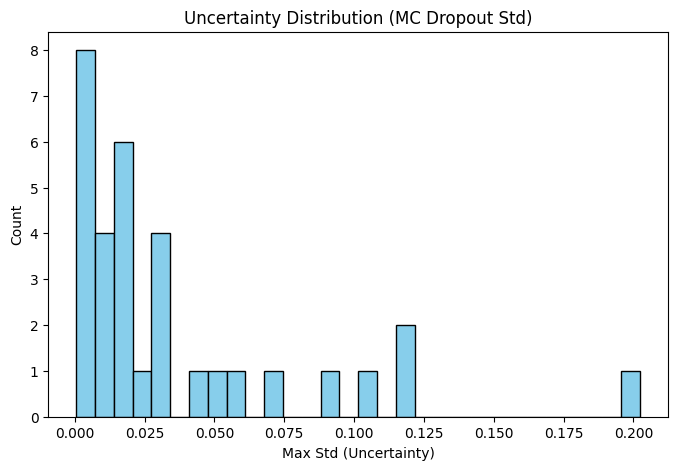

In [115]:
# رسم توزيع الانحراف المعياري
plt.figure(figsize=(8,5))
plt.hist(uncertainties, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Max Std (Uncertainty)')
plt.ylabel('Count')
plt.title('Uncertainty Distribution (MC Dropout Std)')
plt.show()


In [116]:
# run this instead of the previous one
ent = entropy(mean_preds, axis=1)
print("Predictive Entropy:", ent)

Predictive Entropy: [0.07716145 0.21948105 0.00496186 0.06578708 0.01640008 0.04383828
 0.04602662 0.07726789 0.28493643 0.25648695 0.02721202 0.53485423
 0.44966507 0.0461352  0.09201305 0.30726615 0.02375883 0.0024857
 0.07190975 0.14204234 0.02155727 0.10902239 0.01853094 0.0035512
 0.0148782  0.00732295 0.00218067 0.01989795 0.07397073 0.3148677
 0.09243462 0.02540753]


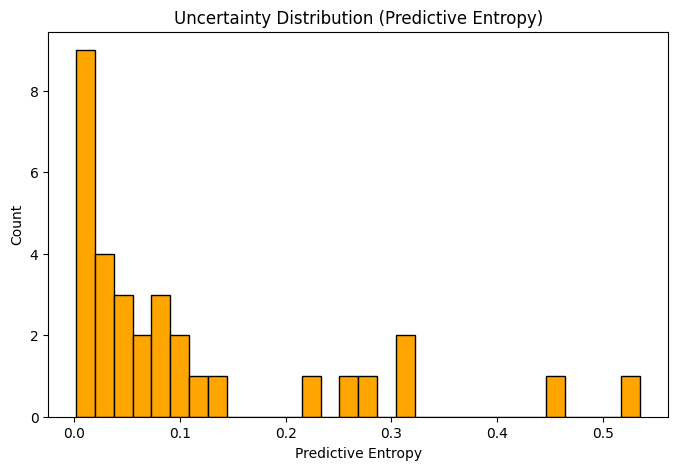

In [117]:
# رسم توزيع الانتروبي
plt.figure(figsize=(8,5))
plt.hist(ent, bins=30, color='orange', edgecolor='black')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.title('Uncertainty Distribution (Predictive Entropy)')
plt.show()



Batch size: 32


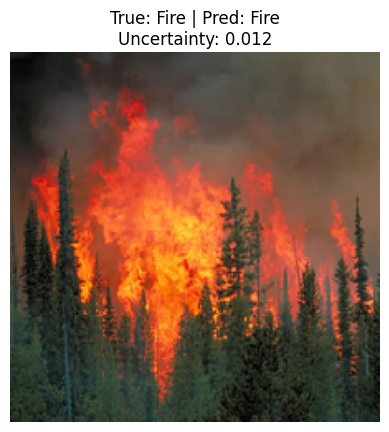

In [118]:
print("Batch size:", batch_images.shape[0])
idx = 10
img = batch_images[idx]
true_label_idx = np.argmax(batch_labels[idx])
true_label = class_names[true_label_idx]
predicted_class = class_names[np.argmax(mean_preds[idx])]
uncertainty = std_preds[idx][np.argmax(mean_preds[idx])]

plt.imshow(img)
plt.axis('off')
plt.title(f"True: {true_label} | Pred: {predicted_class}\nUncertainty: {uncertainty:.3f}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


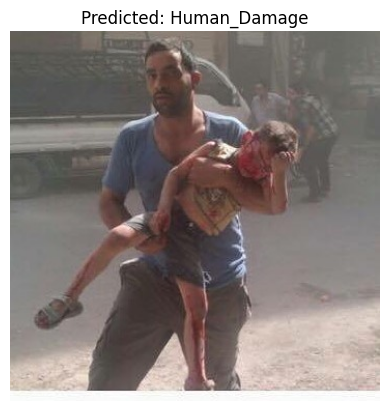

Probabilities: [0.00822998 0.40382615 0.01179988 0.00626772 0.00248081 0.24942726
 0.0288766  0.15180722 0.13728435]


In [104]:
from tensorflow.keras.preprocessing import image

img_path = '/content/Disaster_Data_Split/test/Human_Damage/02_0173.png'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0
preds = model_adv.predict(img_array)
predicted_class = class_names[np.argmax(preds[0])]

plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

print("Probabilities:", preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


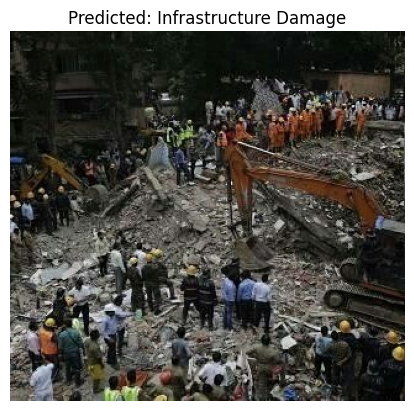

Probabilities: [0.00978228 0.01868511 0.28798702 0.1589146  0.10317615 0.00580697
 0.08763786 0.10967636 0.21833366]


In [108]:
img_path2 = '/content/Disaster_Data_Split/test/Infrastructure Damage/05_01_0193.png'

img = image.load_img(img_path2, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0
preds = model_adv.predict(img_array)
predicted_class = class_names[np.argmax(preds[0])]

plt.imshow(image.load_img(img_path2))
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

print("Probabilities:", preds[0])